In [1]:
import os
import time
import string

import numpy as np
import pandas as pd

from datetime import datetime, timedelta
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates

from tqdm import tqdm

# Font
from matplotlib import font_manager
font_path = "/workspace/fonts/"
font_list = os.listdir(font_path)
for font_file in font_list:
    try:
        font_manager.fontManager.addfont(font_path + font_file)
    except:
        raise Exception(f"Cannot Load {font_path+font_file}")

plt.rcParams["figure.dpi"] = 300

# Handling the DB

In [2570]:
import sys
sys.path.append('/workspace/1.1.KISTI_DB_Manager/')

from KISTI_DB_Manager import manage, preview, processing, plot
import importlib as imp
imp.reload(manage), imp.reload(preview), imp.reload(processing), imp.reload(plot)

plt.rcParams["figure.dpi"] = 300

# WOS

In [4]:
path = '/workspace/share/Data-HDD/Web of Science/Web of Science (2024)/annual/'
flist = sorted([x for x in os.listdir(path) if x[0] != '.'])
flist

['1900_CORE.zip',
 '1945_CORE.zip',
 '1946_CORE.zip',
 '1947_CORE.zip',
 '1948_CORE.zip',
 '1949_CORE.zip',
 '1950_CORE.zip',
 '1951_CORE.zip',
 '1952_CORE.zip',
 '1953_CORE.zip',
 '1954_CORE.zip',
 '1955_CORE.zip',
 '1956_CORE.zip',
 '1957_CORE.zip',
 '1958_CORE.zip',
 '1959_CORE.zip',
 '1960_CORE.zip',
 '1961_CORE.zip',
 '1962_CORE.zip',
 '1963_CORE.zip',
 '1964_CORE.zip',
 '1965_CORE.zip',
 '1966_CORE.zip',
 '1967_CORE.zip',
 '1968_CORE.zip',
 '1969_CORE.zip',
 '1970_CORE.zip',
 '1971_CORE.zip',
 '1972_CORE.zip',
 '1973_CORE.zip',
 '1974_CORE.zip',
 '1975_CORE.zip',
 '1976_CORE.zip',
 '1977_CORE.zip',
 '1978_CORE.zip',
 '1979_CORE.zip',
 '1980_CORE.zip',
 '1981_CORE.zip',
 '1982_CORE.zip',
 '1983_CORE.zip',
 '1984_CORE.zip',
 '1985_CORE.zip',
 '1986_CORE.zip',
 '1987_CORE.zip',
 '1988_CORE.zip',
 '1989_CORE.zip',
 '1990_CORE.zip',
 '1991_CORE.zip',
 '1992_CORE.zip',
 '1993_CORE.zip',
 '1994_CORE.zip',
 '1995_CORE.zip',
 '1996_CORE.zip',
 '1997_CORE.zip',
 '1998_CORE.zip',
 '1999_COR

In [214]:
f = flist[-4]

def WOS_extract_jsons(path, f):
    import zipfile
    import gzip
    import json
    
    with zipfile.ZipFile(path+f, 'r') as zip_ref:
        # List all contents of the ZIP file, assuming there's only one gz file inside
        gz_file_name = [f for f in zip_ref.namelist() if f.endswith('.gz')][0]
        
        # Extract the gz file content
        with zip_ref.open(gz_file_name) as gz_file:
            # Use gzip on the extracted file-like object
            with gzip.open(gz_file, 'rt') as json_file:  # 'rt' mode for text mode reading
                content = json_file.read()
                content = processing.conv_HTML_entities(content)
                # extracted_dict = json.load(json_file)
    xml = processing.read_a_xml(content)
    jsons = xml['records.REC'] # Real Record part
    return jsons

jsons = WOS_extract_jsons(path, f)

Convert HTML Entities: 100%|██████████████████████| 5/5 [04:56<00:00, 59.21s/it]


In [2532]:
origin = ''
forced = {}
# key_pairs = json_to_key_pairs(jsons[:1000], origin)
key_pairs = processing.json_to_key_pairs(jsons[1:1000], origin)
key_pairs_df = processing.key_pair_to_df(key_pairs)
key_pairs_df

,parent,branch,note,type
0,,,,Dict
1,,@r_id_disclaimer,,Value
2,,UID,,Value
3,,dynamic_data,,Dict
4,,static_data,,Dict
...,...,...,...,...
312,static_data__summary__titles,static_data__summary__titles__@count,,Value
313,static_data__summary__titles,static_data__summary__titles__title,,List of Dict
314,static_data__summary__titles__title,static_data__summary__titles__title__#text,,Value in List of Dict
315,static_data__summary__titles__title,static_data__summary__titles__title__@translated,,Value in List of Dict


In [2661]:
msk = key_pairs_df['note'] != ''
key_pairs_df[msk]

,parent,branch,note,type
10,dynamic_data__citation_related__SDG,dynamic_data__citation_related__SDG__sdg_category,List of Value;Value,List of Value
23,dynamic_data__ic_related__oases,dynamic_data__ic_related__oases__oas,Dict;List of Dict,List of Dict
24,dynamic_data__ic_related__oases__oas,dynamic_data__ic_related__oases__oas__@type,Value;Value in List of Dict,Value in List of Dict
30,static_data__contributors,static_data__contributors__contributor,Dict;List of Dict,List of Dict
31,static_data__contributors__contributor,static_data__contributors__contributor__name,Dict;Value in List of Dict,Dict
...,...,...,...,...
273,static_data__summary__names__name,static_data__summary__names__name__email_addr,Value;Value in List of Dict,Value in List of Dict
274,static_data__summary__names__name,static_data__summary__names__name__first_name,Value;Value in List of Dict,Value in List of Dict
275,static_data__summary__names__name,static_data__summary__names__name__full_name,Value;Value in List of Dict,Value in List of Dict
276,static_data__summary__names__name,static_data__summary__names__name__last_name,Value;Value in List of Dict,Value in List of Dict


In [2534]:
sep = '__'
origin = ''
types = key_pairs_df.reset_index().set_index('branch')['type']
index_key = 'UID'

# When The Structure is stiff. with except_keys
# except_key = ['dynamic_data']
# df, df_subs, excepted_part = processing.extract_data_from_jsons(jsons[:], index_key, except_keys)
# When The Structure is unstable.
excepted_reg = processing.excepted_regularization(jsons[1:1000], types, base_key=origin)
df_ex, df_ex_subs, excepted_part = processing.extract_data_from_jsons(excepted_reg, index_key)

100%|█████████████████████████████████████████| 999/999 [00:28<00:00, 35.03it/s]


In [2535]:
df_ex

,@r_id_disclaimer,UID,dynamic_data__ic_related__oases__@count,dynamic_data__ic_related__oases__@is_OA,static_data__contributors__@count,static_data__fullrecord_metadata__abstracts__@count,static_data__fullrecord_metadata__abstracts__abstract__abstract_text__#text,static_data__fullrecord_metadata__abstracts__abstract__abstract_text__@count,static_data__fullrecord_metadata__addresses__@count,static_data__fullrecord_metadata__category_info__headings__@count,...,static_data__summary__publishers__publisher__address_spec__city,static_data__summary__publishers__publisher__address_spec__full_address,static_data__summary__publishers__publisher__names__@count,static_data__summary__publishers__publisher__names__name__@addr_no,static_data__summary__publishers__publisher__names__name__@role,static_data__summary__publishers__publisher__names__name__@seq_no,static_data__summary__publishers__publisher__names__name__display_name,static_data__summary__publishers__publisher__names__name__full_name,static_data__summary__publishers__publisher__names__name__unified_name,static_data__summary__titles__@count
0,ResearcherID data provided by Clarivate Analytics,WOS:001018722200015,,,1,1,%_lt_;p%_lt_;When extended distally due to hig...,1,2,1,...,LAWRENCE,"810 E 10TH ST, LAWRENCE, KS 66044 USA",1,1,publisher,1,ALLEN PRESS INC,ALLEN PRESS INC,Allen Press Inc,6
1,ResearcherID data provided by Clarivate Analytics,WOS:001020897700001,,,3,1,%_lt_;p%_lt_;Cancer is a cellular-based diseas...,1,8,1,...,AMSTERDAM,"RADARWEG 29, 1043 NX AMSTERDAM, NETHERLANDS",1,1,publisher,1,ELSEVIER,ELSEVIER,Elsevier,6
2,ResearcherID data provided by Clarivate Analytics,WOS:000997477300001,1,Yes,4,1,%_lt_;p%_lt_;The amount of global ammonia (NH3...,1,1,1,...,BASEL,"ST ALBAN-ANLAGE 66, CH-4052 BASEL, SWITZERLAND",1,1,publisher,1,MDPI,MDPI,Mdpi,6
3,ResearcherID data provided by Clarivate Analytics,WOS:000985308900010,2,Yes,1,1,%_lt_;p%_lt_;This study compared stress and th...,1,1,1,...,SAN FRANCISCO,"1160 BATTERY STREET, STE 100, SAN FRANCISCO, C...",1,1,publisher,1,PUBLIC LIBRARY SCIENCE,PUBLIC LIBRARY SCIENCE,Public Library Science,6
4,ResearcherID data provided by Clarivate Analytics,WOS:001089658000002,,,1,1,%_lt_;p%_lt_;Background The relationship betwe...,1,2,1,...,DORDRECHT,"VAN GODEWIJCKSTRAAT 30, 3311 GZ DORDRECHT, NET...",1,1,publisher,1,SPRINGER,SPRINGER,Springer Nature,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,ResearcherID data provided by Clarivate Analytics,WOS:000978836200010,,,,1,"%_lt_;p%_lt_;In this paper, we present the eva...",1,2,1,...,NEW YORK,"TWO PARK AVE, NEW YORK, NY 10016-5990 USA",1,1,publisher,1,ASME,ASME,Asme,6
995,ResearcherID data provided by Clarivate Analytics,WOS:000959748100001,1,Yes,1,1,%_lt_;p%_lt_;Along with economic development a...,1,3,1,...,BASEL,"ST ALBAN-ANLAGE 66, CH-4052 BASEL, SWITZERLAND",1,1,publisher,1,MDPI,MDPI,Mdpi,6
996,ResearcherID data provided by Clarivate Analytics,WOS:001043205300132,,,,,,,1,1,...,LONDON,"1 OLIVERS YARD, 55 CITY ROAD, LONDON EC1Y 1SP,...",1,1,publisher,1,SAGE PUBLICATIONS LTD,SAGE PUBLICATIONS LTD,Sage,6
997,ResearcherID data provided by Clarivate Analytics,WOS:000987759600001,2,Yes,2,1,%_lt_;p%_lt_;This study aimed to understand an...,1,4,1,...,BASEL,"ST ALBAN-ANLAGE 66, CH-4052 BASEL, SWITZERLAND",1,1,publisher,1,MDPI,MDPI,Mdpi,6


In [2537]:
df_ex_subs.keys()

dict_keys(['dynamic_data__citation_related__SDG__sdg_category', 'dynamic_data__citation_related__citation_topics__subj-group__subject', 'dynamic_data__cluster_related__identifiers__identifier', 'dynamic_data__ic_related__oases__oas', 'static_data__contributors__contributor', 'static_data__fullrecord_metadata__addresses__address_name', 'static_data__fullrecord_metadata__category_info__headings__heading', 'static_data__fullrecord_metadata__category_info__subheadings__subheading', 'static_data__fullrecord_metadata__category_info__subjects__subject', 'static_data__fullrecord_metadata__fund_ack__grants__grant', 'static_data__fullrecord_metadata__keywords__keyword', 'static_data__fullrecord_metadata__normalized_doctypes__doctype', 'static_data__fullrecord_metadata__references__reference', 'static_data__fullrecord_metadata__reprint_addresses__address_name', 'static_data__item__book_desc', 'static_data__item__keywords_plus__keyword', 'static_data__item__reviewed_work__rw_authors__rw_author', '

/tmp/ipykernel_76293/2068622360.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


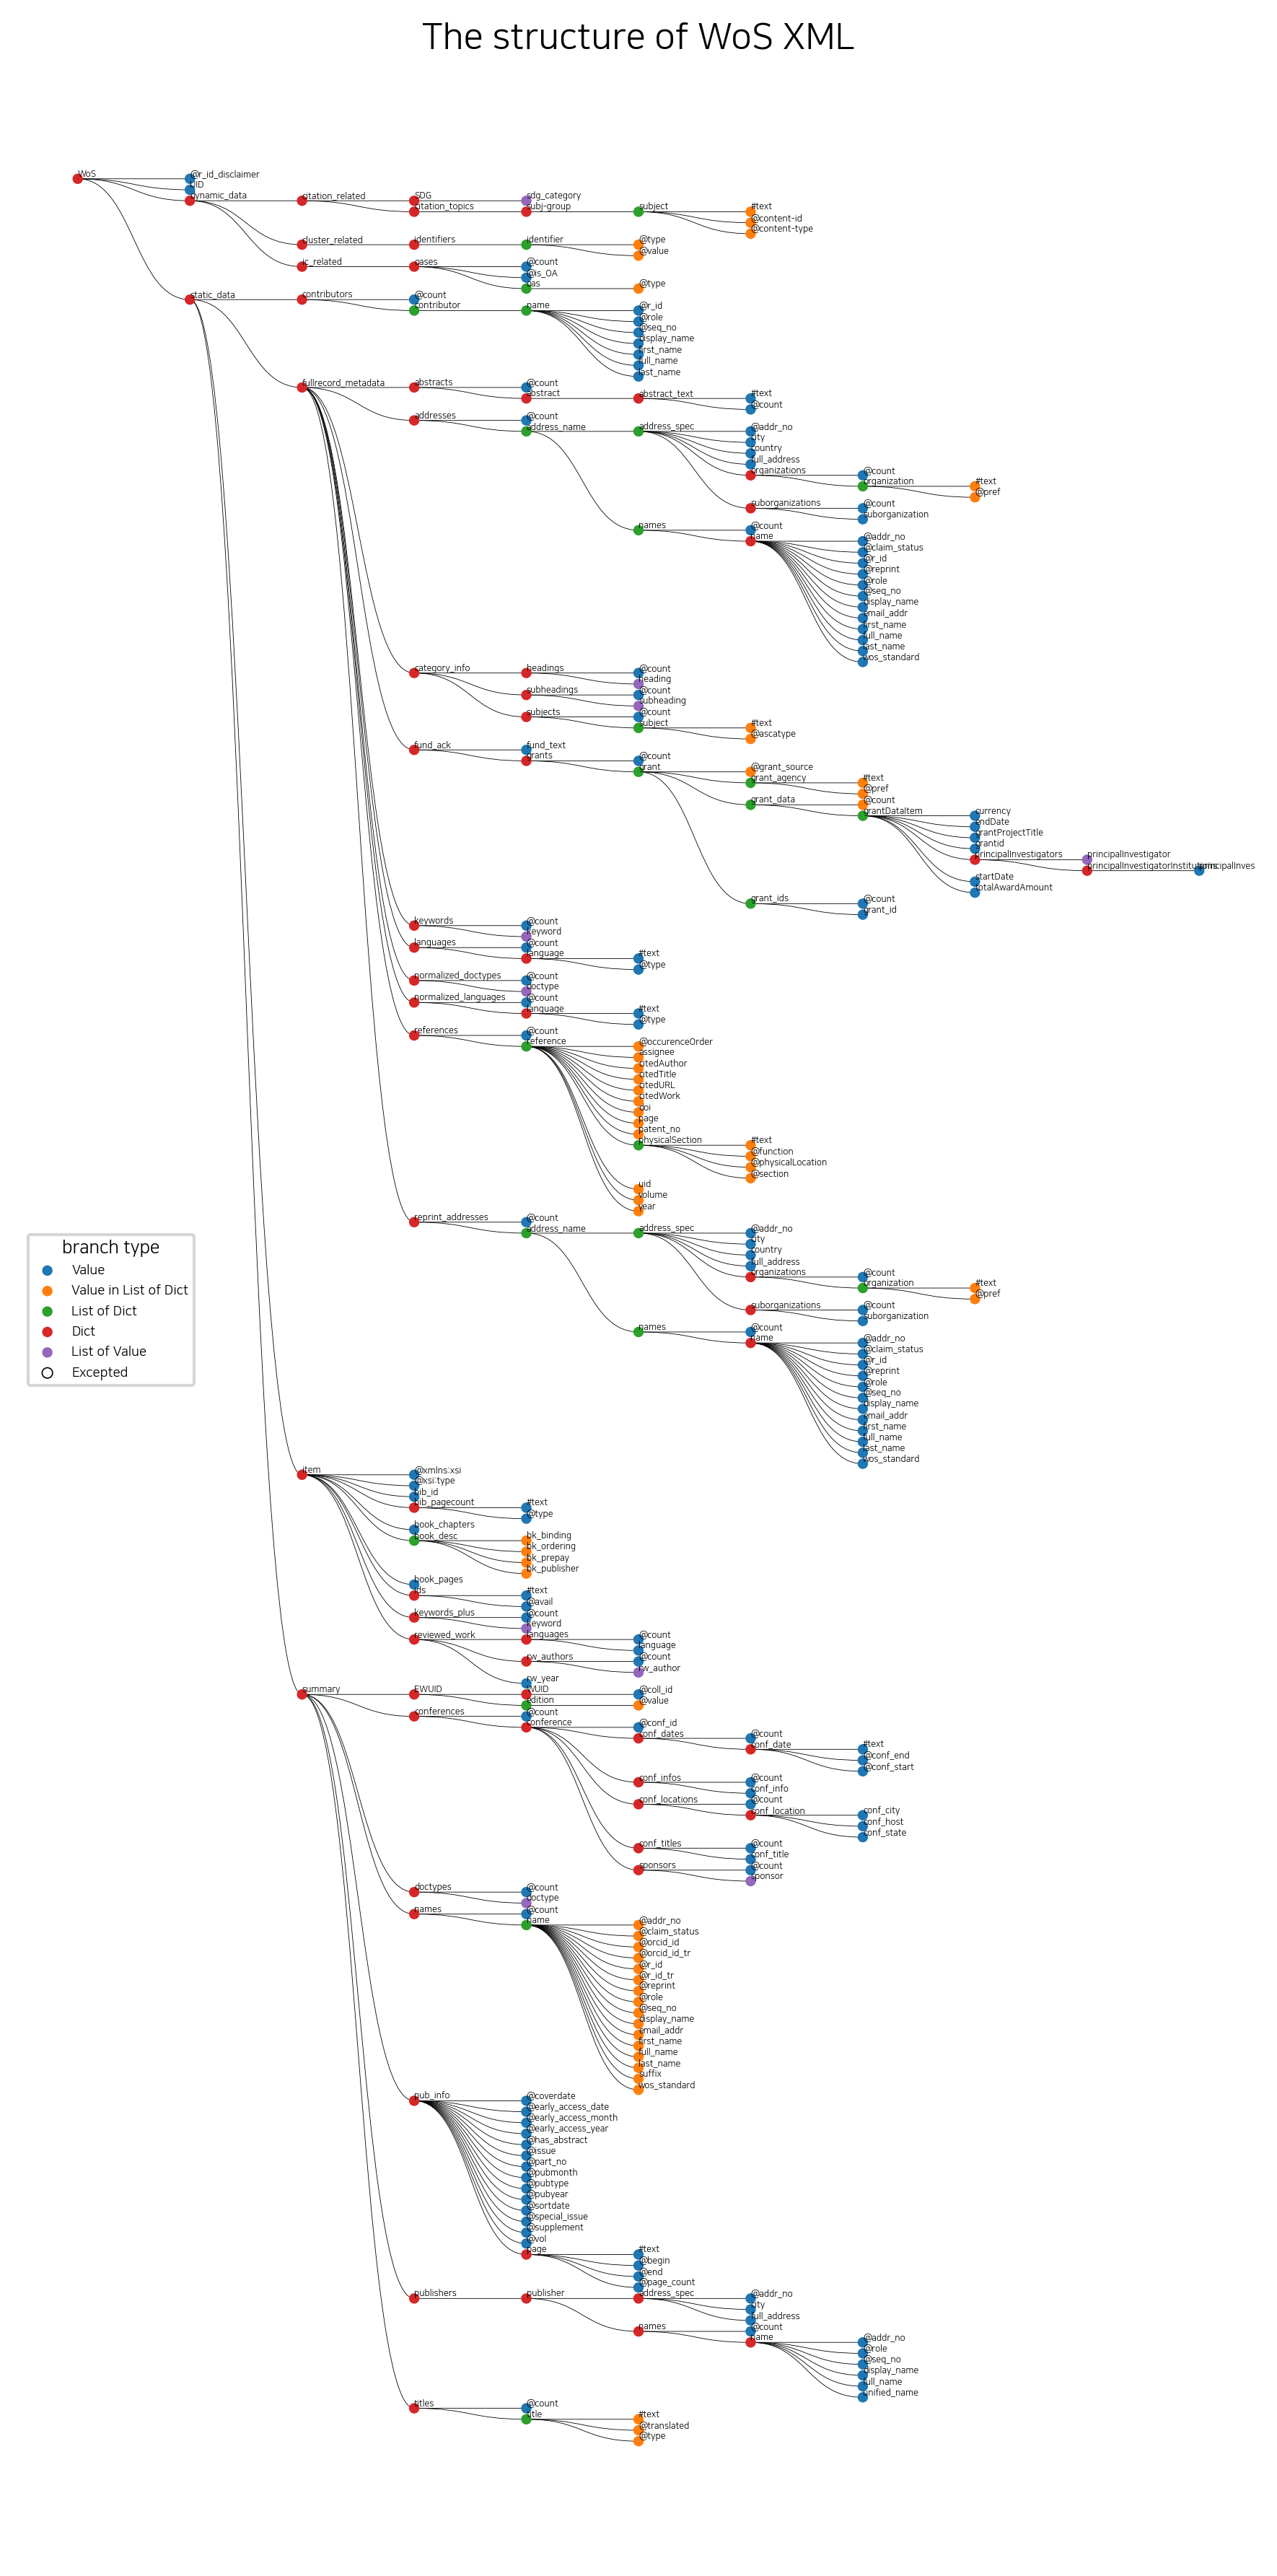

In [2539]:
except_keys = []
origin = 'WoS'
fig = plot.plot_schema(excepted_reg[0], data_name=origin, origin=origin, except_keys=except_keys, forced={},
          legend_loc='center left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=12, DPI=300
                )
plt.tight_layout()
plt.savefig("Structure_WoS_XML.svg")

In [656]:
key_pairs = processing.json_to_key_pairs(excepted_part, origin)
key_pairs_df = processing.key_pair_to_df(key_pairs, True, forced=forced) # without unique_set, Multiple and Single is appear twice
types = key_pairs.set_index('branch')['type']

# Set the base_key
# This example is only one excepted field.
# If two excepted field is contained, the module can be unstable.
for ekey in except_keys:
    base_key = f'{origin}{sep}{except_keys[0]}'
    excepted_reg = processing.excepted_regularization(jsons[1:1000], types, base_key=base_key)
    df_ex, df_ex_subs, excepted_part2 = processing.extract_data_from_jsons(excepted_reg, index_key)

100%|████████████████████████████████████| 51167/51167 [02:42<00:00, 315.35it/s]


In [2556]:
data_config = {
    'PATH': 'Data_Sample/',
    'KEY': 'UID',
    'SEP': '__',
    'table_name': 'WoS_Sample'
}

processing.save_data([df_ex, df_ex_subs], data_config)

'Data_Sample/01__WoS_Sample__MN.ftr' is successfully saved.
'Data_Sample/02__WoS_Sample__MN-SUB__dynamic_data__citation_related__SDG__sdg_category.ftr' is successfully saved.
'Data_Sample/03__WoS_Sample__MN-SUB__dynamic_data__citation_related__citation_topics__subj-group__subject.ftr' is successfully saved.
'Data_Sample/04__WoS_Sample__MN-SUB__dynamic_data__cluster_related__identifiers__identifier.ftr' is successfully saved.
'Data_Sample/05__WoS_Sample__MN-SUB__dynamic_data__ic_related__oases__oas.ftr' is successfully saved.
'Data_Sample/06__WoS_Sample__MN-SUB__static_data__contributors__contributor.ftr' is successfully saved.
Fail to save the Data_Sample/07__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__addresses__address_name.ftr
'Data_Sample/07__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__category_info__headings__heading.ftr' is successfully saved.
'Data_Sample/08__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__category_info__subheadings__subheading.ftr' is 

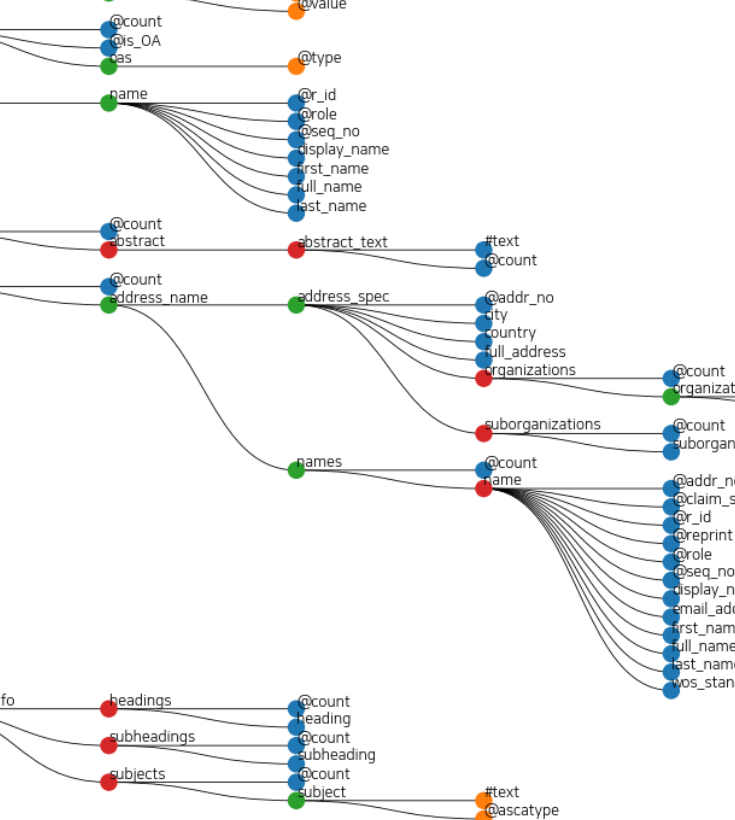

In [2557]:
df_ex_subs['static_data__fullrecord_metadata__addresses__address_name']#['static_data__fullrecord_metadata__addresses__address_name__address_spec'].values[:]

,UID,static_data__fullrecord_metadata__addresses__address_name__address_spec,static_data__fullrecord_metadata__addresses__address_name__names
0,WOS:001018722200015,"{'@addr_no': '1', 'full_address': 'Igdir Univ,...","{'@count': '1', 'name': {'@seq_no': '1', '@rol..."
1,WOS:001018722200015,"{'@addr_no': '2', 'full_address': 'Suleyman De...","{'@count': '1', 'name': {'@seq_no': '2', '@rol..."
0,WOS:001020897700001,"{'@addr_no': '1', 'full_address': 'Univ Tehran...","{'@count': '8', 'name': [{'@seq_no': '1', '@ro..."
1,WOS:001020897700001,"{'@addr_no': '2', 'full_address': 'Iran Univ M...","{'@count': '2', 'name': [{'@seq_no': '3', '@ro..."
2,WOS:001020897700001,"{'@addr_no': '3', 'full_address': 'ACECR, Mota...","{'@count': '1', 'name': {'@seq_no': '7', '@rol..."
...,...,...,...
2,WOS:001114170200001,"{'@addr_no': '3', 'full_address': 'Islamic Aza...","{'@count': '5', 'name': [{'@seq_no': '2', '@ro..."
3,WOS:001114170200001,"{'@addr_no': '4', 'full_address': 'Tabriz Univ...","{'@count': '1', 'name': {'@seq_no': '3', '@rol..."
4,WOS:001114170200001,"{'@addr_no': '5', 'full_address': 'Islamic Aza...","{'@count': '1', 'name': {'@seq_no': '6', '@rol..."
5,WOS:001114170200001,"{'@addr_no': '6', 'full_address': 'Tabriz Univ...","{'@count': '1', 'name': {'@seq_no': '9', '@rol..."


In [2564]:
# From here, the SEP means separation for the tabular file like 'csv'
data_config = {
    'PATH': 'Data_Sample/',
    'KEY': 'UID',
    'SEP': '__',
    'table_name': 'WoS_Sample',
    'Conv_DATETIME': False,
}

params = dict(Extra_ratio=1.5, 
              Min_Year=1900, 
              Max_Year=2100, 
              unique_ratio_th=.5, 
              freq_ratio_th=1e-3)

PATH = data_config['PATH']
flist = sorted([x for x in os.listdir(PATH) if '.ftr' in x])
df_descs = []
_flist = []
for f in flist:
    data_config = preview.update_data_config(f, data_config)
    try:
        df_desc = preview.get_Table_Description(data_config, params)
        df_descs.append(df_desc)
        _flist.append(f)
    except:
        print(f'Fail to make description file with {f}.')
    

Generate the Description file for table `01__WoS_Sample__MN`
Generate the Description file for table `02__WoS_Sample__MN-SUB__dynamic_data__citation_related__SDG__sdg_category`
Generate the Description file for table `03__WoS_Sample__MN-SUB__dynamic_data__citation_related__citation_topics__subj-group__subject`
Generate the Description file for table `04__WoS_Sample__MN-SUB__dynamic_data__cluster_related__identifiers__identifier`
Generate the Description file for table `05__WoS_Sample__MN-SUB__dynamic_data__ic_related__oases__oas`
Fail to make description file with 06__WoS_Sample__MN-SUB__static_data__contributors__contributor.ftr.
Fail to make description file with 07__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__addresses__address_name.ftr.
Generate the Description file for table `07__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__category_info__headings__heading`
Generate the Description file for table `08__WoS_Sample__MN-SUB__static_data__fullrecord_metadata__categor

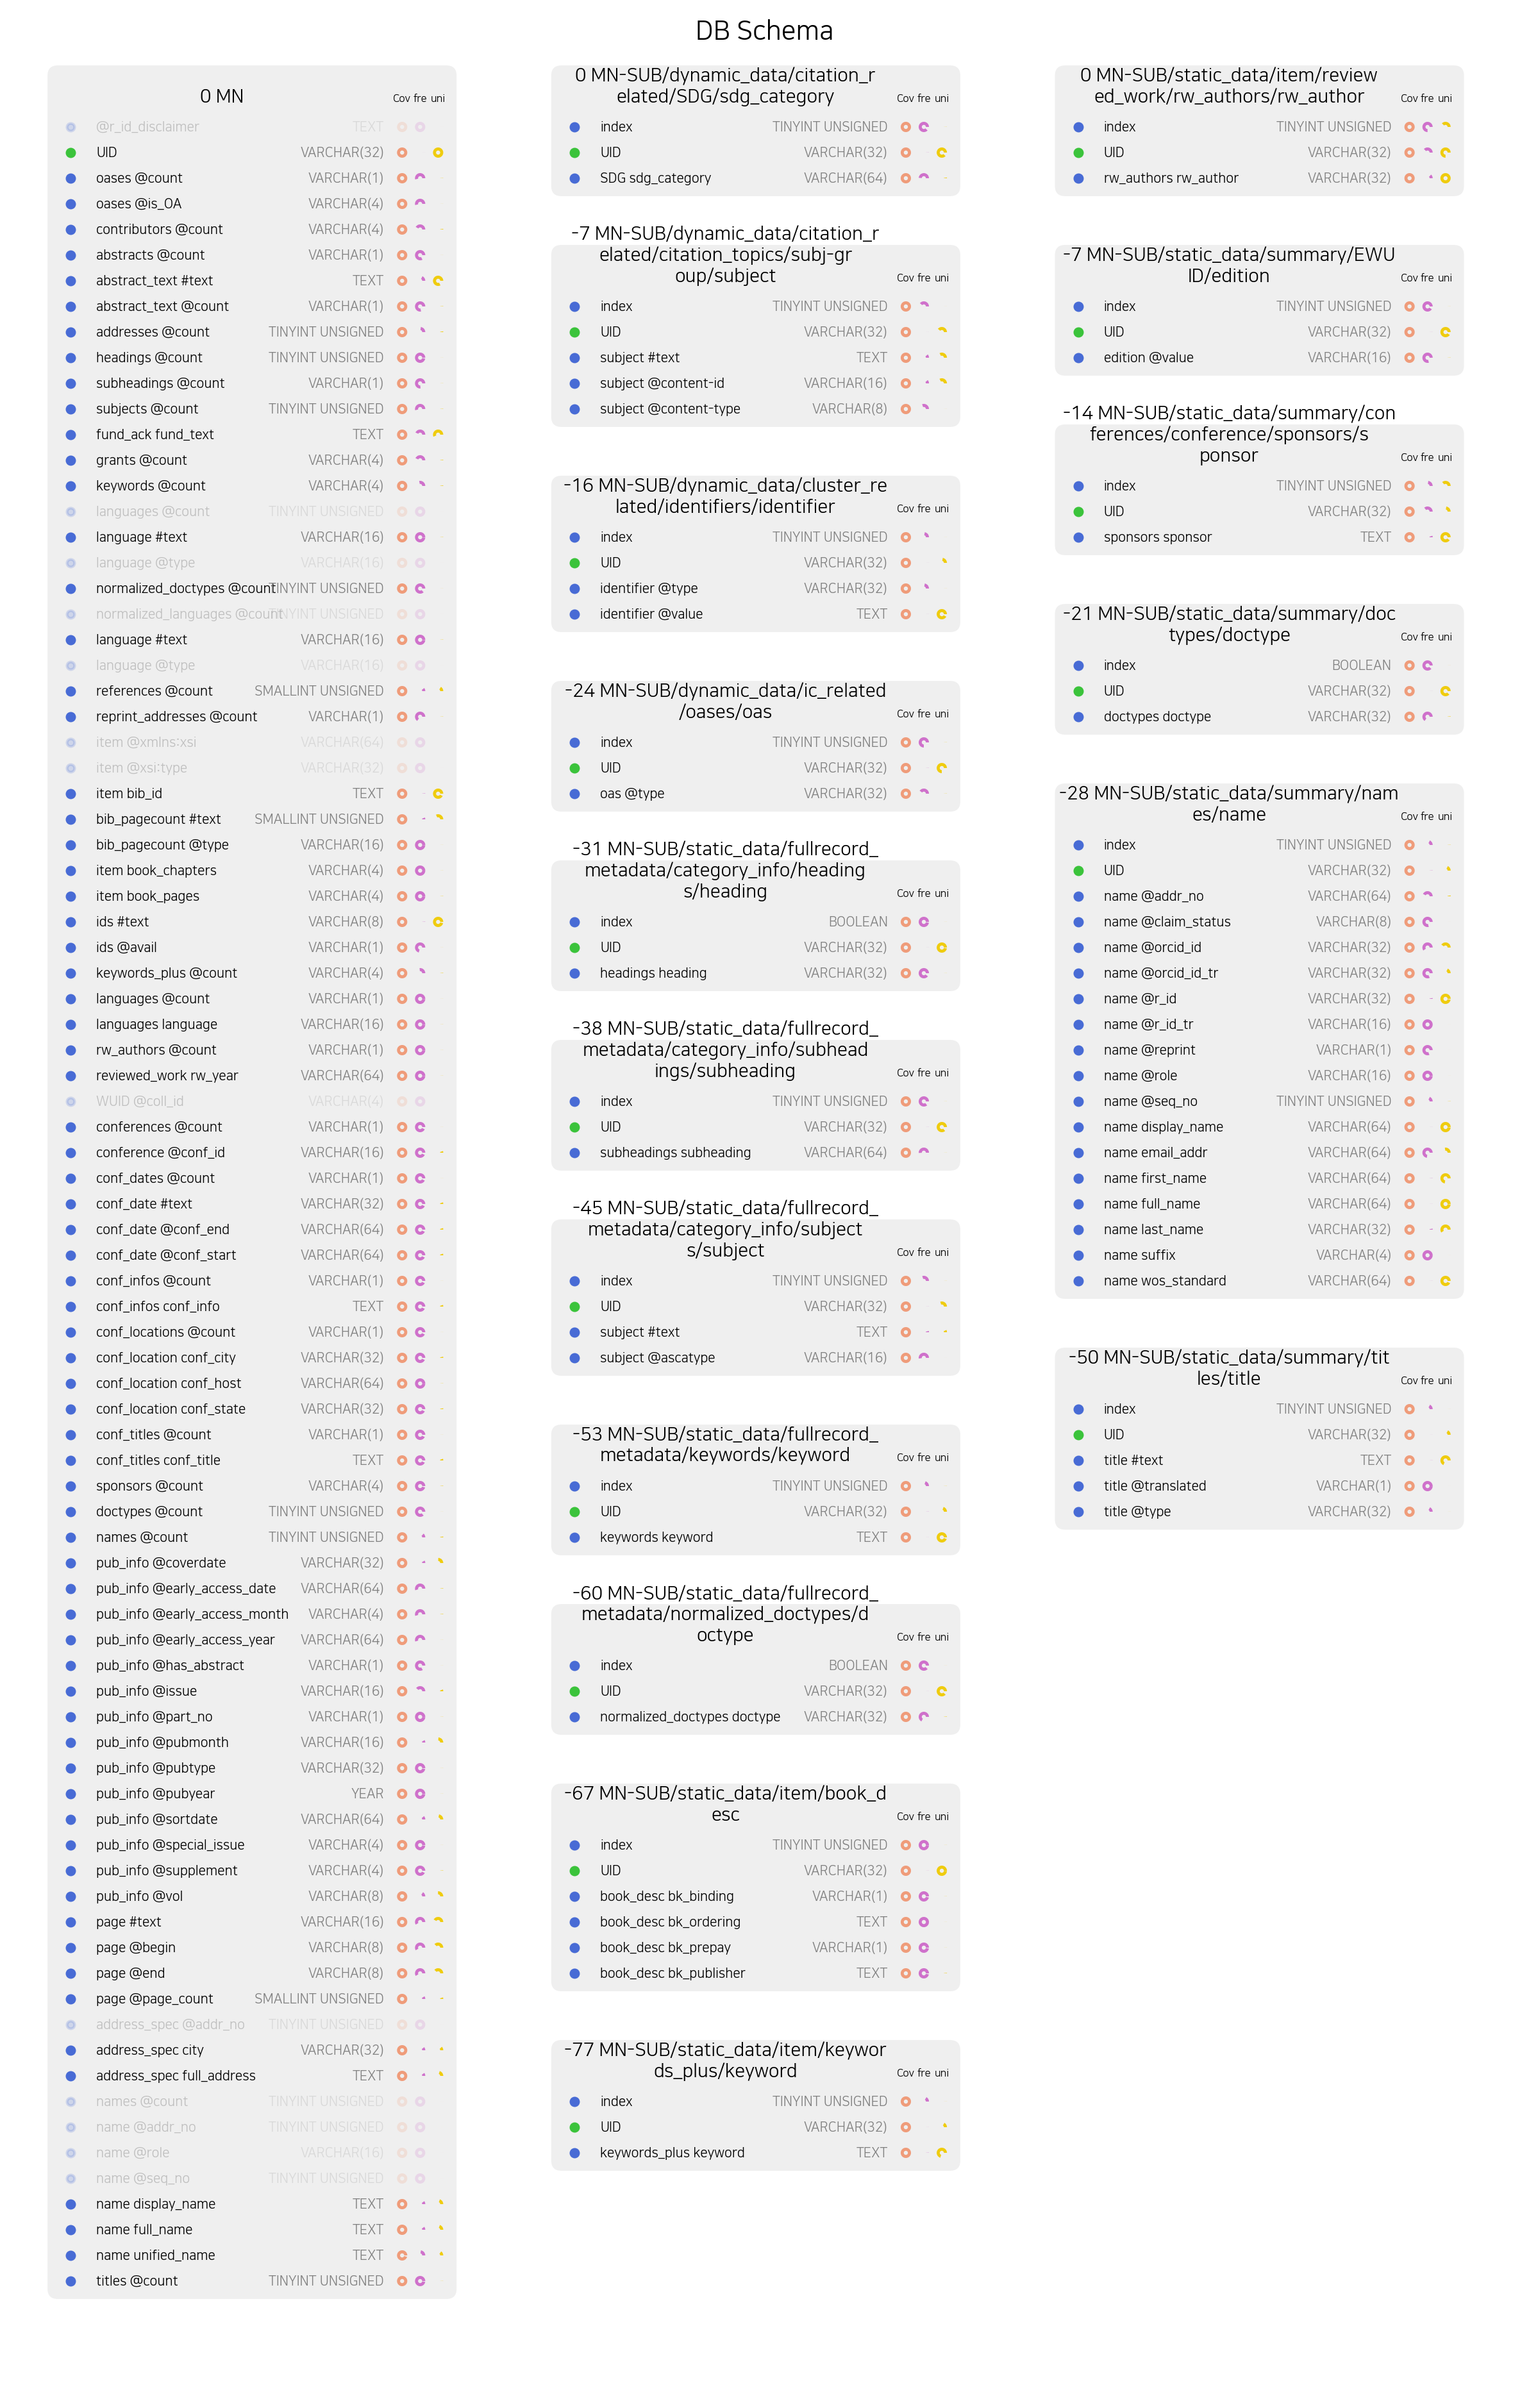

In [2658]:
# legend_loc='center left', node_size=12, font_size=3, X_SIZE=6, Y_SIZE=5, DPI=300
node_size=8
font_size=5
X_SIZE=10
Y_SIZE=24
DPI=300

title='DB Schema'
sep='__'
x_unit=1
table_unit = x_unit*14
features = ['Coverage', 'freq', 'uniq_ratio']

# plt.rcParams['svg.fonttype'] = 'path'
svg_fonttype = 'none'
#svg.fonttype : 'path'         # How to handle SVG fonts:
#    'none': Assume fonts are installed on the machine where the SVG will be viewed.
#    'path': Embed characters as paths -- supported by most SVG renderers
#    'svgfont': Embed characters as SVG fonts -- supported only by Chrome,
#               Opera and Safarids



fig = plot.draw_schema(df_descs, _flist, index_key, Y_SIZE=16)
# plt.savefig("schema.svg")

In [2655]:
import sys
sys.path.append('/workspace/1.1.KISTI_DB_Manager/')

from KISTI_DB_Manager import manage, preview, processing, plot
import importlib as imp
imp.reload(manage), imp.reload(preview), imp.reload(processing), imp.reload(plot)

plt.rcParams["figure.dpi"] = 300

# Excepted branch

## Consider Excepted part
- accumulate the date
    - single > multiple
    - couverage checing
    - coloring
    - optimizion

In [ ]:
data_config = {
    'PATH': 'Data_Sample/',
    'SEP': ',',
    'file_name': 'file_name', # Dummy init value
    'file_type': 'csv', # Dummy init value
    'table_name': 'table_name', # Dummy init value for Exporting
    'out_path': '../Data/SQL/', # Update as needed
    'Conv_DATETIME': False,
}

In [20]:
PATH = '../Data/Funding/KR_NTIS/'
SEP = '\t'
Port = 0 # Port for DB with host
CHARACTER_SET = 'utf8mb4'
COLLATE = 'utf8mb4_unicode_520_ci'

params = dict(Extra_ratio=1.5, 
              Min_Year=1900, 
              Max_Year=2100, 
              unique_ratio_th=.5, 
              freq_ratio_th=1e-3)

db_config = {
    'host': 'localhost',  # Update as needed
    'user': 'user',       # Update as needed
    'password': '1234',       # Update as needed
    'database': 'KR_NTIS_2023_raw'  # Update as needed
}

data_config = {
    'PATH': PATH,
    'SEP': SEP,
    'file_name': 'file_name', # Dummy init value
    'file_type': 'csv', # Dummy init value
    'table_name': 'table_name', # Dummy init value for Exporting
    'out_path': '../Data/SQL/', # Update as needed
    'Conv_DATETIME': False,
}

In [ ]:
manage.init_MySQL()
try:
    manage.drop_DB(db_config['database'], db_config)
except:
    pass
manage.create_DB(db_config['database'], CHARACTER_SET, COLLATE, db_config)


# Generate the Tabular File list
flist = sorted([x for x in os.listdir(PATH) if 'raw.ftr' in x])
for f in tqdm(flist[:]):
    data_config = preview.update_data_config(f, data_config)
    df_desc = preview.get_Table_Description(data_config, params)
    
    # Generate and execute CREATE TABLE SQL
    manage.create_table(data_config, db_config)
    manage.fill_table_from_file(data_config, db_config)
    manage.set_index(db_config, data_config)
    manage.optimize_table(db_config, data_config)

 * Starting MySQL database server mysqld
   ...done.
Failed to drop database `KR_NTIS_2023_raw`. Error: (1049, "Unknown database 'KR_NTIS_2023_raw'")
Database `KR_NTIS_2023_raw` created successfully.


  0%|                                                    | 0/16 [00:00<?, ?it/s]

Generate the Description file for table `1_Projects_raw`
Table `1_Projects_raw` created successfully.
Data inserted into table `1_Projects_raw` successfully.
Set Index the 과제고유번호 on `1_Projects_raw` successfully.


In [ ]:
manage.backup_database_subprocess(db_config, data_config)